# <font color='056938'> **Load modules** </font>

We will load into this notebook some modules with functions that will help you in the development of heuristics and metaheuristics for the solution of travelling salesman problemas

The module `random_generators.py` include the functions to deal with generating random numbers. The ultimate function of this module is to generate a random permutation (solution) of the tsp problem
* Random tour generation: `rand_permutation`

The module `tsp_tools` provides different functions to help from the data reading to the solution ploting
* Data reading: `read_data(filepath)`
> `filepath`: the route to the file with the instance's data
* Distance calculation: `calculate_distances`
* Data display: `print_TSPdata()
* Solution evaluation: `tsp_distance`
* Tour display: `plot_tsp_route()`
* Plot the search trayectory `plot_trace(trace)`

In [1]:

import random_generators as ran_gen
import tsp_tools as TSPtools
import pandas as pd

# <font color='056938'> **Instance generation** </font>

## <font color='8EC044'> **Data reading** </font>

We will use the clasical test instances stored in  [TSPlib](http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/), the format of these instances include a heading with the following information:

>NAME: berlin52

>TYPE: TSP

>COMMENT: 52 locations in Berlin (Groetschel)

>DIMENSION: 52

>EDGE_WEIGHT_TYPE: EUC_2D

>NODE_COORD_SECTION

Then, n lines with the coordinates of the cities in the following format (cityID, Coordinate X, Coordinate Y):

**id cX cY**

Knowing this structure we are going to read two files

* `berlin52.tsp`
* `prueba10.tsp`



Then we read the data file

In [2]:
data = TSPtools.read_data("berlin52.tsp")             #Read the data
data

[[565.0, 575.0],
 [25.0, 185.0],
 [345.0, 750.0],
 [945.0, 685.0],
 [845.0, 655.0],
 [880.0, 660.0],
 [25.0, 230.0],
 [525.0, 1000.0],
 [580.0, 1175.0],
 [650.0, 1130.0],
 [1605.0, 620.0],
 [1220.0, 580.0],
 [1465.0, 200.0],
 [1530.0, 5.0],
 [845.0, 680.0],
 [725.0, 370.0],
 [145.0, 665.0],
 [415.0, 635.0],
 [510.0, 875.0],
 [560.0, 365.0],
 [300.0, 465.0],
 [520.0, 585.0],
 [480.0, 415.0],
 [835.0, 625.0],
 [975.0, 580.0],
 [1215.0, 245.0],
 [1320.0, 315.0],
 [1250.0, 400.0],
 [660.0, 180.0],
 [410.0, 250.0],
 [420.0, 555.0],
 [575.0, 665.0],
 [1150.0, 1160.0],
 [700.0, 580.0],
 [685.0, 595.0],
 [685.0, 610.0],
 [770.0, 610.0],
 [795.0, 645.0],
 [720.0, 635.0],
 [760.0, 650.0],
 [475.0, 960.0],
 [95.0, 260.0],
 [875.0, 920.0],
 [700.0, 500.0],
 [555.0, 815.0],
 [830.0, 485.0],
 [1170.0, 65.0],
 [830.0, 610.0],
 [605.0, 625.0],
 [595.0, 360.0],
 [1340.0, 725.0],
 [1740.0, 245.0]]

We get the size of the instance. That is, the number of nodes `n`

In [3]:
n = len(data)
n

52

## <font color='8EC044'> **Distance calculation** </font>

We are going to use the $\tt{scipy.spatial}$ package to calculate the distances trhough the function `calculate_distances()`



In [4]:
distances=TSPtools.calculate_distances(data)
distances

array([[   0.        ,  666.10809934,  281.11385594, ...,  217.08293346,
         789.38267019, 1220.46097848],
       [ 666.10809934,    0.        ,  649.32657423, ...,  596.25917184,
        1421.55724471, 1716.04924172],
       [ 281.11385594,  649.32657423,    0.        , ...,  463.24939288,
         995.3140208 , 1483.59361012],
       ...,
       [ 217.08293346,  596.25917184,  463.24939288, ...,    0.        ,
         829.60834133, 1150.76061803],
       [ 789.38267019, 1421.55724471,  995.3140208 , ...,  829.60834133,
           0.        ,  624.81997407],
       [1220.46097848, 1716.04924172, 1483.59361012, ..., 1150.76061803,
         624.81997407,    0.        ]])

# <font color='056938'> **Initial solution generation** </font>

The code in the modules we load reuses the code of [Taillard](http://mistic.heig-vd.ch/taillard/articles.dir/taillard.html) (2023) that in turn is based on [L'Ecuyer](https://www.iro.umontreal.ca/~lecuyer/) random number generator for random.

It is used to generate a random solution. That is an inital random permutation

In [5]:
sol=ran_gen.rand_permutation(n)
sol

[21,
 10,
 49,
 47,
 30,
 6,
 0,
 20,
 11,
 42,
 17,
 18,
 12,
 36,
 32,
 26,
 41,
 24,
 4,
 40,
 33,
 27,
 38,
 28,
 3,
 39,
 50,
 14,
 51,
 23,
 15,
 34,
 35,
 9,
 19,
 8,
 7,
 1,
 46,
 37,
 22,
 13,
 25,
 48,
 16,
 29,
 45,
 43,
 5,
 31,
 44,
 2]

# <font color='056938'> **Solution evaluation** </font>

## <font color='8EC044'> **Objective function calculation** </font>

Now we define use function `tsp_distance()` to evaluate the objective function of a given permutation

For the case of the solution we previuosly generated it will be:

In [6]:
obj_fn = TSPtools.tsp_distance(distances,sol)
print("Distance of the permutation --> " + str(obj_fn))

Distance of the permutation --> 29680.253971123482


## <font color='8EC044'> **Solution visualization** </font>

We can print the scatter plot of the data points using the function `print_TSPdata()`

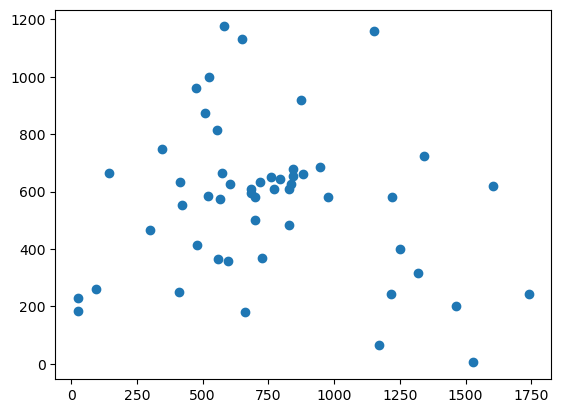

In [7]:
TSPtools.print_TSPdata(data)

Additionally, we can plot the route for a given solution `plot_tsp_route()`

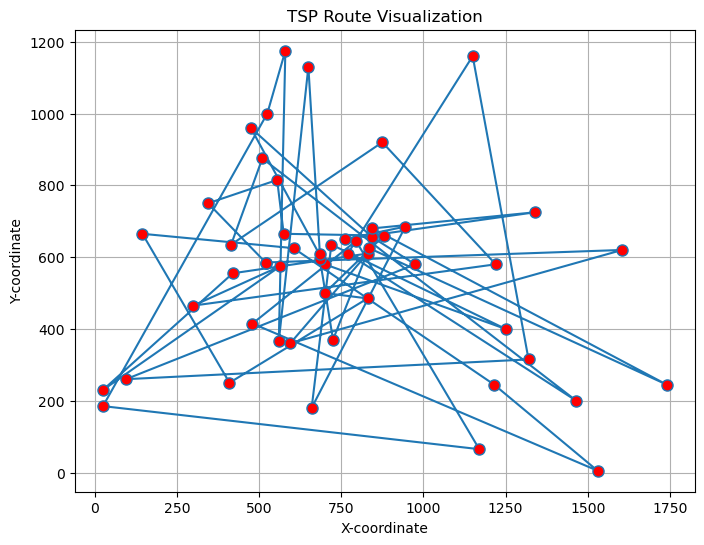

In [8]:
TSPtools.plot_tsp_route(data, sol)

# <font color='056938'> **Tabu search/Adaptive memory porgramming** </font>

Now we are going to explore the usage of memory as a powerfull search control. Originally introduced by [Fred Glover](https://www.researchgate.net/profile/Fred-Glover/research) with the name of tabu search (Glover 1989,1990) , it has been named Adaptive memory programming by a few authors to highlight the several uses that a memory of past solutons visited and moves performed by **any**  metaheurstic.



#### <font color='46B8A9'> **Ejercicio** </font>

Run the algorith with different parameters triying to get faster, better  or more stable performance

## <font color='8EC044'> **Our algorithm** </font>

We are going to implement our own version assembling the different componentes we would need. For a basic implementation of the Tabu search those componentes are:
* A component that generates an initial solution (i.e., `rand_permutation()`)
* A component that evaluates a solution (i.e., `tsp_distance()`)
* A movement to use in the local search `swap()`
* A component that compares to solutions
* A component to evaluate the acceptabilty criterion `acceptability()`

We first define the functions that are needed. The function `swap()` performs the swapping of elements `i` and `j `and returns the new solution and a list of attributes to be added to the tabu list

In [9]:
import numpy as np
def swap(current_solution, i, j):
  """
    Swap two elements in a solution and return the modified solution along
    with the affected arcs.

    Args:
        current_solution (list): The current solution to be modified.
        i (int): Index of the first element to be swapped.
        j (int): Index of the second element to be swapped.

    Returns:
        tuple: A tuple containing the modified solution (neighbor) and a list
               of affected arcs.
  """
  n = len(current_solution)
  neighbor = np.copy(current_solution)
  neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
  attrib =[(neighbor[i-1], neighbor[i]),
         (neighbor[i], neighbor[(i+1) % n]),
         (neighbor[j-1], neighbor[j]),
         (neighbor[j], neighbor[(j+1) % n])]

  return neighbor, attrib

The function acceptability evaluates if a solution is tabu or not and whther we could accepted it depending on the aspiration criteria we defined

In [10]:
def aceptability(tabu_list, neigh_arcs, best_obj, neigh_obj):
  return not(any(element in neigh_arcs for element in tabu_list)) or (neigh_obj < best_obj)

Whit these elements we define our **basic Tabu search**

In [11]:

def tabu_search(num_cities, distance_matrix, max_iter, tabu_size):
    # create initial soluction and initialize the tabu list
    current_solution = ran_gen.rand_permutation(num_cities)
    best_solution = np.copy(current_solution)
    best_obj = TSPtools.tsp_distance(distance_matrix, best_solution)
    tabu_list = []

    # we are going to keep the trace of the search saving the solutions we visit
    trace = []
    # Repeat for a given number of iterations
    for iter in range(max_iter):
        neighborhood = []
        flag = False
        for i in range(num_cities):
            for j in range(i + 1, num_cities):
                # Swap two cities in the current solution to create a neighbor
                neighbor, arcs = swap(current_solution, i, j)
                # Evaluate acceptability
                neigh_obj = TSPtools.tsp_distance(distance_matrix, neighbor)
                if aceptability(tabu_list, arcs, best_obj, neigh_obj): # It is not tabu
                  neighborhood.append((neighbor, neigh_obj, arcs))
                # Aspiration criterion
                elif neigh_obj < best_obj:
                  neighborhood.append((neighbor, neigh_obj, arcs))

        # Find the best aceptable neighbor
        neighborhood = sorted(neighborhood, key=lambda x: x[1]) # sort the list based on obj value
        best_neighbor = neighborhood[0][0]

        # Update the current solution
        current_solution = best_neighbor

        # Update the best solution if necessary
        if neighborhood[0][1] < best_obj:
          best_solution = np.copy(current_solution)
          best_obj = neighborhood[0][1]



        # Update search's trace
        trace.append([iter, neighborhood[0][1], best_obj])
        # Add the atributes to the tabu list
        tabu_list += neighborhood[0][2]


        # Remove the oldest move from the tabu list if it exceeds the tabu size
        if len(tabu_list) > tabu_size:
          remove = len(tabu_list) - tabu_size
          tabu_list = tabu_list[remove:]
    print(tabu_list)
    return best_solution, trace

**How the different neighborhoods work**

Lets run an example and see the solution we obtain with our tabu search

In [12]:
n=len(data)
sol=ran_gen.rand_permutation(n)
obj_fn = TSPtools.tsp_distance(distances,sol)
best_solution, trace = tabu_search(n, distances, 200, 5)
best_obj = TSPtools.tsp_distance(distances, best_solution)
best_obj

[(np.int64(33), np.int64(47)), (np.int64(37), np.int64(43)), (np.int64(43), np.int64(19)), (np.int64(39), np.int64(36)), (np.int64(36), np.int64(15))]


np.float64(11048.05571254921)

We now plot  the solution generated

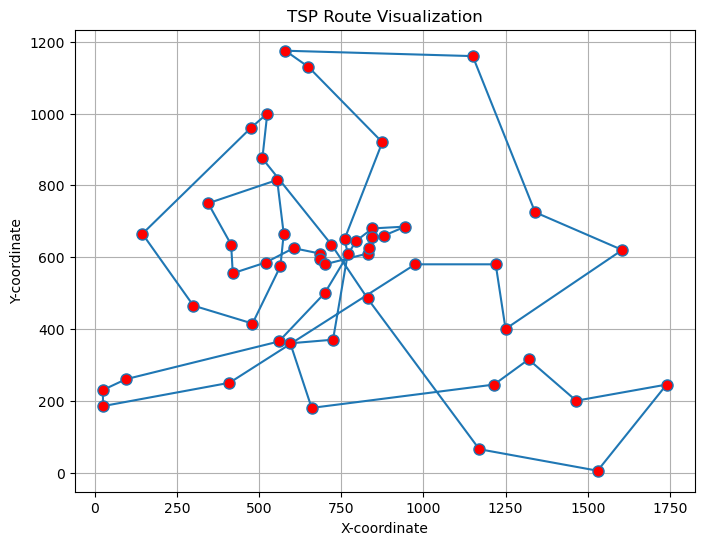

In [13]:
TSPtools.plot_tsp_route(data, best_solution)

Lets explore now the trajectory of the soution

In [ ]:
TSPtools.plot_trace(trace)

#### <font color='46B8A9'> **Exercise** </font>

Change the algoritm to use other neighborhood structures and **define which things have to be stored in the memory**

+ test a **2-opt neighborhood** or an **insert neighborhood**
+ Compare your TS to see the effect of the neighborhood structure

# <font color='056938'> **References** </font>

Glover, F. (1989). Tabu search—part I. ORSA Journal on computing, 1(3), 190-206.

Glover, F. (1990). Tabu search—part II. ORSA Journal on computing, 2(1), 4-32.

